# MVP — Machine Learning & Analytics

**Nome:** Amanda Figueiredo Clemente  
**Matrícula:** 4052026000065  
**Data:** 04/07/2026  
**Dataset:** IBM HR Analytics Employee Attrition & Performance

**Link:** https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fpavansubhasht%2Fibm-hr-analytics-attrition-dataset   
**Tipo de problema:** Classificação

# 1. Definição do problema

## 1.1 Descrição do problema


Uma das características mais relevantes de uma empresa saúdavel é a sua capacidade de reter funcionários. Organizações que possuem taxas altas de rotatividade (employee attrition) geralmente enfrentam desafios relacionados aos seus processos internos, como recrutamento e seleção, cultura organizacional,plano de carreria, benefícios, dentre outros fatores que podem desestimular a permanência dos(as) colaboradores(as).

Esse é um desafio importante para as empresas, pois o desligamento de funcionários(as) gera impactos financeiros, operacionais e estratégicos. Quando um(a) colaborador(a) deixa a organização, esse movimento pode ser revertido para a empresa como custo de recrutamento, treinamento, além da possível perda de conhecimento e experiência acumulados. Sendo assim, ferramentas que auxiliem na compreensão de fatores que influenciam a saída de colaboradores(as) tornam-se valiosas para apoiar o planejamento e o desenvolviemnto de estratégias voltadas à retenção de talentos.

Neste MVP, o problema consiste em prever se um(a) funcionário(a) possui maior probabilidade de deixar a empresa com base em algumas informações como idade, renda, tempo de empresa, realização de horas extras e outras características (variáveis) presentes na base IBM HR Analytics Employee Attrition & Performance.

Essa solução pode apoiar atores como profissionais de Recursos Humanos (RH), gestores de pessoas e outras lideranças organizacionais que queiram identificar, em seu quadro de funcionároios, pessoas com maior risco de desligamento.

Esse é um problema adequado para a aplicação de ML por requerer a análise simultânea de diversas variáveis. Identificar esses processos somente por meio da análise humana seria uma atividade complexa, custosa e sujeita a vieses. Por outro lado, as técnicas de ML são capazes de analisar esses dados, identificar relações entre as variáveis e gerar previsões que poderão apoiar a tomada de decisão de forma mais eficaz, barata e baseada em métodos consistentes e bem estabelecidos.  

## 1.2 Objetivo do MVP

O objetivo de MVP é realizar uma classificação de cada colaborador(a) em uma das duas categorias possíveis:

- `0`- O(a) funcionário(a) não saiu da empresa.


- `1` - O(a) funcionário(a) saiu da empresa.

Além da previsão, o trabalho busca comparar abordagens simples e modelos baseados em árvores, identificar suas limitações e compreender quais características aparecem com maior relevância nas previsões.

## 1.3 Tipo de problema

**Tipo de problema escolhido:** Classificação  
**Justificativa:** O que esse modelo irá prever é uma categoria (Yes,No, ou dito de outra forma, Saiu, Não saiu), além disso existem apenas duas categorias possíveis então se trata de um problema de classificação binária.


## 1.4 Premissas, hipóteses e critérios de sucesso

Parte-se da hipótese de que as características demográficas e profissionais disponíveis na base contêm padrões associados ao desligamento dos(as) funcionários(as) e podem ser utilizadas para estimar a variável `Attrition`.

Como a classe `Yes` é minoritária, a acurácia não será utilizada isoladamente para selecionar o melhor modelo. O F1-score da classe positiva será adotado como métrica principal, por equilibrar precisão e recall, enquanto ROC-AUC, precisão, recall e acurácia serão analisadas como métricas complementares.

A avaliação será considerada bem-sucedida se pelo menos um dos modelos treinados superar o baseline no F1-score e apresentar capacidade efetiva de identificar casos de desligamento em dados de teste. A solução final será escolhida pelo maior F1-score, mantendo-se a análise das demais métricas para verificar os tipos de erro e as limitações do modelo.


# 2. Ambiente, bibliotecas e reprodutibilidade



In [426]:
# === Setup básico e reprodutibilidade ===

import time
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score, precision_score, RocCurveDisplay, make_scorer
)

# Seed e versão

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("Seed:", RANDOM_STATE)


Python: 3.12.13
scikit-learn: 1.6.1
Seed: 42


# 3. Carregamento de dados

## 3.1 Fonte dos dados

O dataset utilizado é o IBM HR Analytics Employee Attrition & Performance, originalmente publicado no Kaggle (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset). Para o contexto dessa avaliação, o arquico CSV foi disponibilizado de forma pública no GitHub e carregado diretamente por url, conforme será possível checar nos códigos a seguir.

O conjunto de dados é composto por 1.470 registros de funcionários e 35 variáveis, contendo informações demográficas, profissionais e relacionadas ao ambiente de trabalho. Entre os atributos disponíveis estão idade, departamento, cargo, renda mensal, tempo de empresa, satisfação no trabalho, realização de horas extras, distância entre residência e trabalho, nível de escolaridade, frequência de viagens a trabalho, entre outros. A variável-alvo da base é Attrition, que indica se o funcionário permaneceu na empresa (No) ou se deixou a organização (Yes).

A base foi escolhida por ser pequena, mas com dimensão suficiente para o trabalho, tabular, pública e adequada para desenvolver o MVP de classificação.


In [427]:
# Carregando os dados

url = "https://raw.githubusercontent.com/Amandaficle/base_mvp1_avs/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(url)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3.3 Visão geral do dataset

Nesta etapa foram verificadas as dimensões da base, os tipos das variáveis, valores ausentes, duplicatas, algumas estatísticas descritivas e quantidade de categorias.

In [428]:
print("Dimensões do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Dimensões do dataset: (1470, 35)

Tipos de dados:


,tipo
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [429]:
#Verificando a existência de valores ausentes por variável

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

#Identificando variáveis que possuem algum valor ausente

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0 ]

if missing.empty:
  print("Resultado: Não foram identificados valores ausentes na base.")
else:
  print("Resultado: Foram identificados valores ausentes nas seguintes variáveis:")
  display(missing.to_frame("Quantidade de valores ausentes"))


Valores ausentes por coluna:


,ausentes
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Resultado: Não foram identificados valores ausentes na base.


In [430]:
#Verificando registros duplicados

print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [431]:
#Exibindo registros para avaliação inicial da base

display(df.sample(5, random_state=RANDOM_STATE))

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,...,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,...,4,80,0,16,3,4,13,11,3,7


In [432]:
# Identificando variáveis numéricas
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

#Principais estatísticas descritivas das variáveis numéricas

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [433]:
# Identificando variáveis categóricas e a quantidade de categorias

categorical_cols=df.select_dtypes(include=["object"]).columns

pd.DataFrame({ "variavel": categorical_cols,
              "qtd_categorias": [df[col].nunique() for col in categorical_cols]}).sort_values("qtd_categorias", ascending=False)

,variavel,qtd_categorias
5,JobRole,9
3,EducationField,6
6,MaritalStatus,3
2,Department,3
1,BusinessTravel,3
0,Attrition,2
4,Gender,2
8,OverTime,2
7,Over18,1


## 3.4 Dicionário de dados

A base contém 35 colunas, contudo o dicionário abaixo destaca as variáveis mais relevantes para compreensão do problema e da modelagem.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `Attrition` | Alvo | Indica se o funcionário saiu da empresa (`Yes`) ou não (`No`) | Alvo | Será transformada em variável binária |
| `Age` | Numérica | Idade do funcionário(a) | Sim | Pode estar relacionada a fase de carreira |
| `BusinessTravel` | Categórica | Frequência de viagens a trabalho | Sim | Pode indicar rotina do(a) funcionário(a) e exposição a deslocamentos |
| `Department` | Categórica | Departamento do(a) funcionário(a) | Sim | Área de atuação |
| `DistanceFromHome` | Numérica | Distância entre residência e trabalho | Sim | Pode influenciar permanência |
| `JobRole` | Categórica | Cargo/função | Sim | Representa perfil profissional |
| `MonthlyIncome` | Numérica | Renda mensal | Sim | Indicador muito relevante para retenção |
| `OverTime` | Categórica | Indica se faz horas extras | Sim | Variável potencialmente associada a saída |
| `JobSatisfaction` | Numérica ordinal | Satisfação com o trabalho | Sim | Indicador de satisfação |
| `YearsAtCompany` | Numérica | Anos na empresa | Sim | Mede vínculo com a organização |
| `EmployeeNumber` | Identificador | Identificador do(a) funcionário(a) | Não | Removida por não representar padrão generalizavel |
| `EmployeeCount`, `Over18`, `StandardHours` | Constantes | Colunas sem variabilidade útil | Não | Removidas da modelagem |


# 4. Análise exploratória dos dados




In [434]:
#Verificando a distribuição da variável_alvo (Attrition)

contagem_attrition = df["Attrition"].value_counts()
percentual_attrition = df["Attrition"].value_counts(normalize=True) * 100

pd.DataFrame({
    "quantidade": contagem_attrition,
    "percentual": percentual_attrition.round(2)})

,quantidade,percentual
Attrition,,
No,1233,83.88
Yes,237,16.12


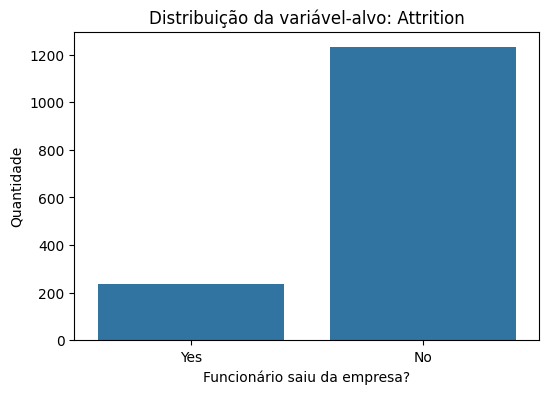

In [435]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Distribuição da variável-alvo: Attrition")
plt.xlabel("Funcionário saiu da empresa?")
plt.ylabel("Quantidade")
plt.show()

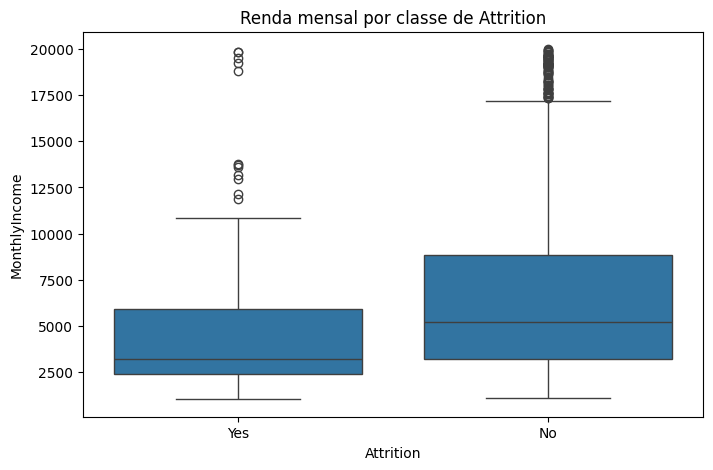

In [436]:
#Comparando a renda entre funcionários(as) que saíram e que ficaram na empresa

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Renda mensal por classe de Attrition")
plt.xlabel("Attrition")
plt.ylabel("MonthlyIncome")
plt.show()

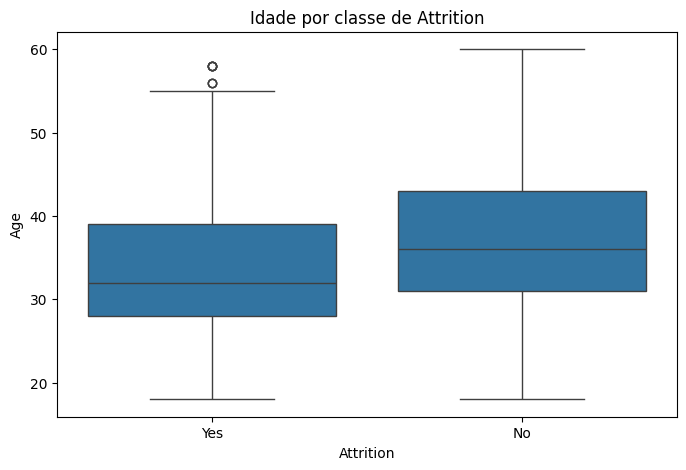

In [437]:
#Comparando a distribuição da idade entre funcionários(as) que saíram e que ficaram na empresa

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="Age")
plt.title("Idade por classe de Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


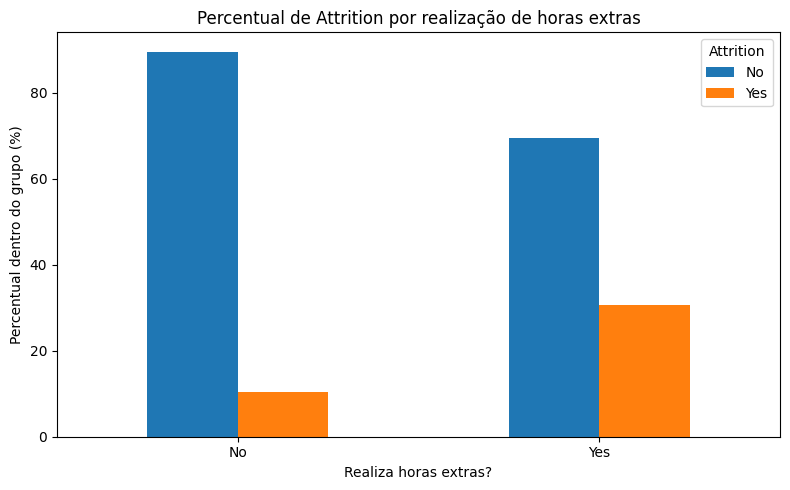

In [438]:
# Comparando a taxa de desligamento dentro de cada grupo de horas extras
percentual_overtime = (
    pd.crosstab(df["OverTime"], df["Attrition"], normalize="index")
    .mul(100)
    .round(2)
)

display(percentual_overtime)

percentual_overtime.plot(kind="bar", figsize=(8, 5))
plt.title("Percentual de Attrition por realização de horas extras")
plt.xlabel("Realiza horas extras?")
plt.ylabel("Percentual dentro do grupo (%)")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

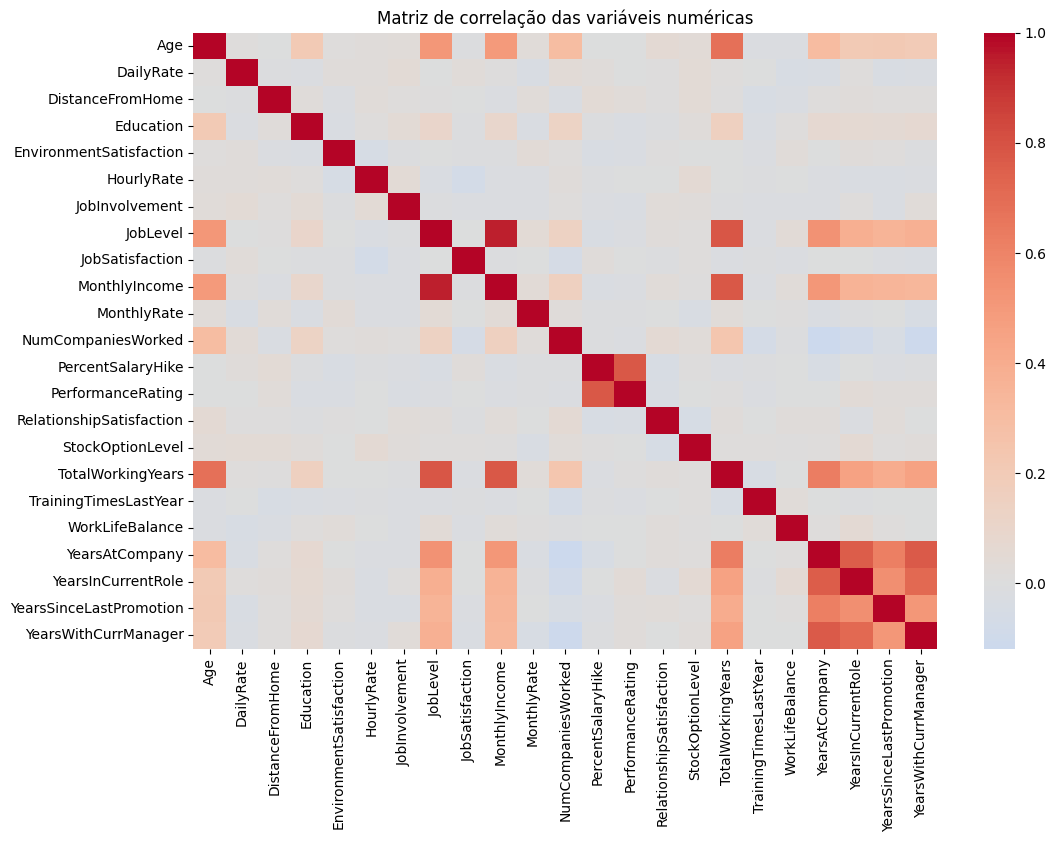

In [439]:
# Correlações entre variáveis numéricas úteis para análise
colunas_excluir_correlacao = ["EmployeeNumber", "EmployeeCount", "StandardHours"]
colunas_correlacao = [col for col in numeric_cols if col not in colunas_excluir_correlacao]

plt.figure(figsize=(12, 8))
corr = df[colunas_correlacao].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlação das variáveis numéricas")
plt.show()

## 4.1 Síntese da análise exploratória

A base possui 1.470 registros e 35 variáveis, sem valores ausentes ou duplicatas. A classe positiva é minoritária: 237 funcionários deixaram a empresa (`Yes`), correspondendo a 16,12% da amostra, enquanto 1.233 permaneceram (`No`). Esse desbalanceamento torna a acurácia insuficiente como critério isolado e justifica priorizar F1-score, recall, precision e ROC-AUC.

Os boxplots indicam que funcionários que deixaram a organização tendem a apresentar menor renda mensal e menor idade. Esses padrões são descritivos e não significam causalidade.

A relação com horas extras ficou particularmente clara: entre quem não fazia horas extras, 10,44% deixaram a empresa; entre quem fazia, a taxa foi de 30,53%. A diferença sugere que `OverTime` contém informação preditiva relevante, mas não permite concluir que horas extras sejam a causa do desligamento.

A matriz de correlação mostra relações entre idade, renda, nível do cargo, experiência profissional e tempo na empresa. Como parte dessas variáveis mede dimensões próximas da trajetória profissional, a importância individual de cada uma deve ser interpretada com cautela.

Em síntese, a EDA sustenta a viabilidade do problema de classificação, evidencia o desbalanceamento e orienta tanto a escolha das métricas quanto a necessidade de avaliar falsos negativos com atenção.


# 5. Preparação dos dados

A variável `Attrition` será transformada em variável binária:

- `Yes` = 1;
- `No` = 0.

Nesta etapa também serão removidas colunas que não ajudam na modelagem ou não trazem variabilidade relevante:

- `EmployeeNumber`: identificador do funcionário;
- `EmployeeCount`: valor constante;
- `Over18`: valor constante;
- `StandardHours`: valor constante.

As variáveis numéricas e categóricas serão tratadas em pipelines separados. Isso evita vazamento de dados, pois imputação, padronização e codificação serão ajustadas apenas no conjunto de treino.


In [440]:
df_modelo = df.copy()

df_modelo["Attrition_bin"] = df_modelo["Attrition"].map({"No": 0, "Yes": 1})

colunas_remover = [
    "Attrition",
    "Attrition_bin",
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

X = df_modelo.drop(columns=[col for col in colunas_remover if col in df_modelo.columns])
y = df_modelo["Attrition_bin"]

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)
print("Distribuição do alvo:")
print(y.value_counts(normalize=True).round(3))

Dimensões de X: (1470, 30)
Dimensões de y: (1470,)
Distribuição do alvo:
Attrition_bin
0    0.839
1    0.161
Name: proportion, dtype: float64


In [441]:
colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("Colunas categóricas:", colunas_categoricas)

Colunas numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Colunas categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


# 6. Divisão dos dados - treino e teste

A base será dividida em treino e teste. Como há desbalanceamento na variável-alvo, conforme observado na análise exploratória, será usada divisão estratificada, com o objetivo de preservar proporções semelhantes de funcionários(as) que saíram e que permaneceram nos conjuntos de treino e teste.

In [442]:
# === Divisão dos dados ===

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção do alvo no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("Proporção do alvo no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: (1176, 30)
Teste: (294, 30)
Proporção do alvo no treino:
Attrition_bin
0    0.838
1    0.162
Name: proportion, dtype: float64
Proporção do alvo no teste:
Attrition_bin
0    0.84
1    0.16
Name: proportion, dtype: float64


## 6.1 Justificativa da divisão

Foi usada uma divisão holdout com 80% dos dados para treino e 20% para teste. Essa estratégia é simples, adequada ao tamanho da base e suficiente para um MVP.

Como a classe `Attrition = Yes` é minoritária, a divisão foi feita com `stratify=y`, preservando proporções semelhantes das classes nos conjuntos de treino e teste. Isso reduz o risco de uma avaliação distorcida por uma separação pouco representativa.

As transformações de pré-processamento foram incluídas em pipelines, o que ajuda a evitar vazamento de dados, pois os ajustes são aprendidos apenas no conjunto de treino.

# 7. Pré-processamento e pipeline

Serão criados dois pré-processadores:

- Um deles com padronização para Regressão Logística;
- e outro sem padronização para modelos baseados em árvores.


In [443]:
#Função para criar o OneHotEncoder com compatibilidade entre versões do Scikit-learn

def criar_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


#Pré-processamento para a Regressão Logística, com padronização das variáveis numéricas

preprocessador_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", criar_one_hot_encoder())
        ]), colunas_categoricas)
    ])

#Pré-processamento para modelos baseados em árvores, sem padronização das variáveis numéricas

preprocessador_arvore = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), colunas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", criar_one_hot_encoder())
        ]), colunas_categoricas)
    ])

## 7.1 Decisões de pré-processamento

As variáveis numéricas foram imputadas pela mediana, uma escolha robusta para possíveis valores extremos. Embora a base não tenha valores ausentes, manter a imputação no pipeline torna o fluxo mais seguro e reproduzível.

As variáveis categóricas foram imputadas pela categoria mais frequente e codificadas com One-Hot Encoding, permitindo que modelos do `scikit-learn` utilizem essas informações.

A Regressão Logística recebeu padronização nas variáveis numéricas porque modelos lineares podem ser sensíveis à escala. Já os modelos baseados em árvores não exigem padronização, então usam um pré-processador sem `StandardScaler`.

Foram removidas colunas identificadoras ou constantes, como `EmployeeNumber`, `EmployeeCount`, `Over18` e `StandardHours`, pois não ajudam a aprender padrões generalizáveis.


# 8. Modelagem e treinamento

Serão avaliados os seguintes modelos:

- **Baseline:** `DummyClassifier`, que prevê sempre a classe majoritária.
- **Modelo 1:** Regressão Logística.
- **Modelo 2:** Random Forest.
- **Modelo 3:** Gradient Boosting.

Como a classe `Attrition = Yes` é minoritária, conforme já abordado, a análise não deve depender apenas da acurácia. As métricas principais serão `recall`, `precision`, `F1-score` e `ROC-AUC`.

## 8.1 Justificativa dos modelos

O `DummyClassifier` foi escolhido como baseline por representar uma regra ingênua: prever sempre a classe majoritária. Ele ajuda a verificar se os modelos realmente aprendem padrões úteis.

A Regressão Logística foi escolhida por ser um modelo simples, rápido e interpretavel para classificação binária.

O Random Forest foi escolhido por lidar bem com relações não lineares e interações entre variáveis, além de funcionar bem em dados tabulares.

O Gradient Boosting foi incluído como uma segunda abordagem baseada em árvores, permitindo comparar uma técnica de boosting com o Random Forest.


In [444]:
# Validação cruzada estratificada usada apenas no conjunto de treino
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

metricas_cv = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}


def avaliar_modelo_cv(nome, modelo, X_train, y_train):
    """Avalia um pipeline por validação cruzada sem tocar no conjunto de teste."""
    inicio = time.time()
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_estratificada,
        scoring=metricas_cv,
        return_train_score=True,
        n_jobs=-1
    )
    return {
        "modelo": nome,
        "accuracy_cv": scores["test_accuracy"].mean(),
        "precision_cv": scores["test_precision"].mean(),
        "recall_cv": scores["test_recall"].mean(),
        "f1_cv": scores["test_f1"].mean(),
        "f1_cv_desvio": scores["test_f1"].std(),
        "roc_auc_cv": scores["test_roc_auc"].mean(),
        "f1_treino": scores["train_f1"].mean(),
        "gap_treino_cv": scores["train_f1"].mean() - scores["test_f1"].mean(),
        "tempo_cv_seg": time.time() - inicio
    }

In [445]:
#Criando os pipelines com o baseline e os modelos que serão avaliados

modelos = {
    "Baseline - classe majoritária": Pipeline([
        ("preprocessador", preprocessador_arvore),
        ("modelo", DummyClassifier(strategy="most_frequent"))
    ]),

    "Regressão Logística": Pipeline([
        ("preprocessador", preprocessador_linear),
        ("modelo", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessador", preprocessador_arvore),
        ("modelo", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessador", preprocessador_arvore),
        ("modelo", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

In [412]:
# Comparação inicial usando somente o conjunto de treino
resultados_cv = []

for nome, modelo in modelos.items():
    resultados_cv.append(avaliar_modelo_cv(nome, modelo, X_train, y_train))

resultados_cv_df = (
    pd.DataFrame(resultados_cv)
    .sort_values("f1_cv", ascending=False)
    .reset_index(drop=True)
)

resultados_cv_df.round(3)

,modelo,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_cv_desvio,roc_auc_cv,f1_treino,gap_treino_cv,tempo_cv_seg
0,Regressão Logística,0.753,0.372,0.737,0.492,0.034,0.827,0.550,0.058,0.423
1,Gradient Boosting,0.872,0.734,0.337,0.456,0.077,0.813,0.897,0.440,2.526
2,Random Forest,0.861,0.876,0.174,0.284,0.078,0.805,1.000,0.716,4.048
3,Baseline - classe majoritária,0.838,0.000,0.000,0.000,0.000,0.500,0.000,0.000,4.314


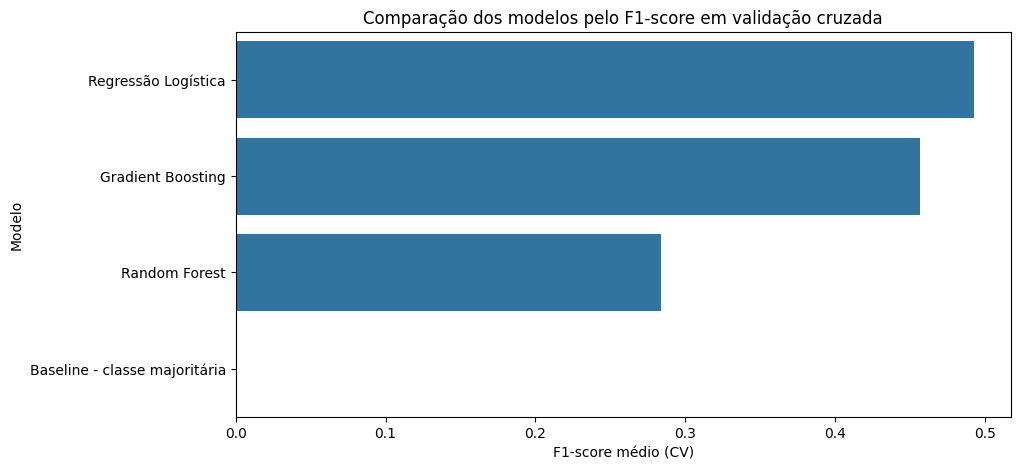

In [413]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_cv_df, x="f1_cv", y="modelo")
plt.title("Comparação dos modelos pelo F1-score em validação cruzada")
plt.xlabel("F1-score médio (CV)")
plt.ylabel("Modelo")
plt.show()

# 9 Análise dos resultados iniciais

A comparação inicial foi feita por validação cruzada estratificada usando somente o conjunto de treino. O teste permaneceu reservado para a avaliação final.

A Regressão Logística apresentou o melhor resultado inicial: F1 médio de 0,492, recall de 0,737 e ROC-AUC de 0,827. Seu gap entre treino e validação foi de apenas 0,058, indicando comportamento relativamente estável.

O Gradient Boosting obteve F1 médio de 0,456 e precisão de 0,734, mas recall de apenas 0,337. Isso significa que seus alertas foram mais precisos, porém muitos desligamentos deixaram de ser identificados. Além disso, o gap de F1 entre treino e validação foi de 0,440, sinal de overfitting.

O Random Forest inicial teve F1 médio de 0,284 e recall de 0,174. Embora sua precisão tenha sido alta, o F1 de treino chegou a 1,000 e o gap treino-validação foi de 0,716, evidenciando forte overfitting na configuração padrão.

O baseline alcançou acurácia de 0,838, mas F1 e recall iguais a zero, pois sempre previu a classe majoritária. Esse resultado confirma por que a acurácia não pode orientar sozinha a escolha do modelo.

# 10. Otimização de hiperparâmetros

O Random Forest será otimizado porque a configuração inicial apresentou forte overfitting e baixo desempenho de validação, tornando pertinente investigar se o controle da complexidade das árvores melhora sua capacidade de generalização.

Os hiperparâmetros avaliados serão:

- `n_estimators`: quantidade de árvores;
- `max_depth`: profundidade máxima das árvores;
- `min_samples_leaf`: quantidade mínima de amostras em folhas.


A métrica usada no `GridSearchCV` será o `F1-score`, pois ela equilibra precisão e recall para a classe positiva.


In [414]:
#Criando o pipeline do Random Forest que será utilizado na otimização

rf_pipeline = Pipeline([
    ("preprocessador", preprocessador_arvore),
    ("modelo", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])


#Definindo os hiperparâmetros e valores que serão testados

param_grid = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [None, 5, 10],
    "modelo__min_samples_leaf": [1, 3, 5]
}


# Configurando o GridSearchCV para buscar a melhor combinação de hiperparâmetros com base no F1-Score e utilizando validação cruzada com 5 divisões

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_estratificada,
    n_jobs=-1
)


#Executando a busca pelos melhores hiperparâmetros utilizando apenas os dados de treino

grid_search.fit(X_train, y_train)


#Exibindo a melhor combinação encontrada e o F1-Score médio obtido na validação cruzada

print("Melhores hiperparâmetros:")
print(grid_search.best_params_)
print("Melhor F1 médio na validação cruzada:", grid_search.best_score_)


Melhores hiperparâmetros:
{'modelo__max_depth': 5, 'modelo__min_samples_leaf': 3, 'modelo__n_estimators': 100}
Melhor F1 médio na validação cruzada: 0.4971195047637472


In [415]:
# Recuperando o Random Forest otimizado
melhor_rf = grid_search.best_estimator_

# Avaliando a configuração otimizada nas mesmas dobras de validação
resultado_rf_otimizado_cv = avaliar_modelo_cv(
    "Random Forest otimizado",
    melhor_rf,
    X_train,
    y_train
)

comparacao_validacao = pd.concat(
    [resultados_cv_df, pd.DataFrame([resultado_rf_otimizado_cv])],
    ignore_index=True
).sort_values("f1_cv", ascending=False).reset_index(drop=True)

# Escolha do modelo final sem consultar o teste
melhor_modelo_nome = comparacao_validacao.iloc[0]["modelo"]
modelo_final = melhor_rf if melhor_modelo_nome == "Random Forest otimizado" else modelos[melhor_modelo_nome]

print("Modelo escolhido pela validação cruzada:", melhor_modelo_nome)
display(comparacao_validacao.round(3))

# Avaliação única no teste reservado
inicio = time.time()
modelo_final.fit(X_train, y_train)
tempo_treino_final = time.time() - inicio
melhor_pred = modelo_final.predict(X_test)
melhor_proba = modelo_final.predict_proba(X_test)[:, 1]

resultados_final_teste = pd.DataFrame([{
    "modelo": melhor_modelo_nome,
    "accuracy_teste": accuracy_score(y_test, melhor_pred),
    "precision_teste": precision_score(y_test, melhor_pred, zero_division=0),
    "recall_teste": recall_score(y_test, melhor_pred, zero_division=0),
    "f1_teste": f1_score(y_test, melhor_pred, zero_division=0),
    "roc_auc_teste": roc_auc_score(y_test, melhor_proba),
    "tempo_treino_final_seg": tempo_treino_final
}])

print("Resultado final no conjunto de teste:")
display(resultados_final_teste.round(3))

Modelo escolhido pela validação cruzada: Random Forest otimizado


,modelo,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_cv_desvio,roc_auc_cv,f1_treino,gap_treino_cv,tempo_cv_seg
0,Random Forest otimizado,0.845,0.531,0.479,0.497,0.068,0.791,0.744,0.247,1.905
1,Regressão Logística,0.753,0.372,0.737,0.492,0.034,0.827,0.550,0.058,0.423
2,Gradient Boosting,0.872,0.734,0.337,0.456,0.077,0.813,0.897,0.440,2.526
3,Random Forest,0.861,0.876,0.174,0.284,0.078,0.805,1.000,0.716,4.048
4,Baseline - classe majoritária,0.838,0.000,0.000,0.000,0.000,0.500,0.000,0.000,4.314


Resultado final no conjunto de teste:


,modelo,accuracy_teste,precision_teste,recall_teste,f1_teste,roc_auc_teste,tempo_treino_final_seg
0,Random Forest otimizado,0.813,0.423,0.468,0.444,0.789,0.314


## 10.1 Discussão da otimização

A otimização foi aplicada apenas ao Random Forest e testou 18 combinações de n_estimators, max_depth e min_samples_leaf, usando F1-score e validação cruzada estratificada com cinco divisões.

A melhor configuração foi:

n_estimators = 100;
max_depth = 5;
min_samples_leaf = 3.
O F1 médio aumentou de 0,284 no Random Forest inicial para aproximadamente 0,497 no modelo otimizado. A limitação da profundidade e o aumento do tamanho mínimo das folhas reduziram a complexidade das árvores e melhoraram a generalização.

A otimização foi feita exclusivamente no conjunto de treino.

# 11. Avaliação final dos resultados

O Random Forest otimizado foi selecionado pelo maior F1 médio na validação cruzada. No teste reservado, composto por 294 registros, o modelo obteve:

- acurácia: 0,813;
- precisão da classe positiva: 0,423;
- recall da classe positiva: 0,468;
- F1-score da classe positiva: 0,444;
- ROC-AUC: 0,789.

A acurácia não deve ser interpretada isoladamente, pois 83,88% da base pertence à classe `No`. O F1 de 0,444 mostra que o modelo encontrou algum equilíbrio entre identificar desligamentos e evitar alertas incorretos, mas seu desempenho ainda é moderado.

O recall de 0,468 significa que o modelo reconheceu 22 dos 47 desligamentos presentes no teste. A precisão de 0,423 indica que menos da metade dos alertas positivos estava correta. Portanto, o modelo é útil como exercício preditivo, mas ainda insuficiente para orientar sozinho decisões reais de RH.

In [416]:
# Resumo do modelo final
print("Modelo final:", melhor_modelo_nome)
print(classification_report(y_test, melhor_pred, target_names=["No", "Yes"]))

Modelo final: Random Forest otimizado
              precision    recall  f1-score   support

          No       0.90      0.88      0.89       247
         Yes       0.42      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.66      0.67      0.67       294
weighted avg       0.82      0.81      0.82       294



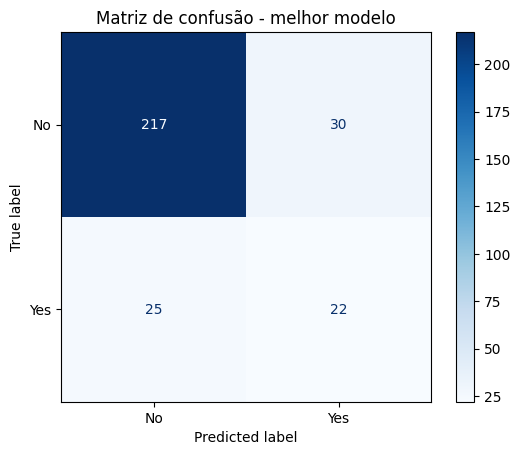

In [417]:
# Calculando a matriz de confusão do melhor modelo

cm = confusion_matrix(y_test, melhor_pred)


# Exibindo a matriz de confusão para visualizar os acertos e erros de classificação

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusão - melhor modelo")
plt.show()

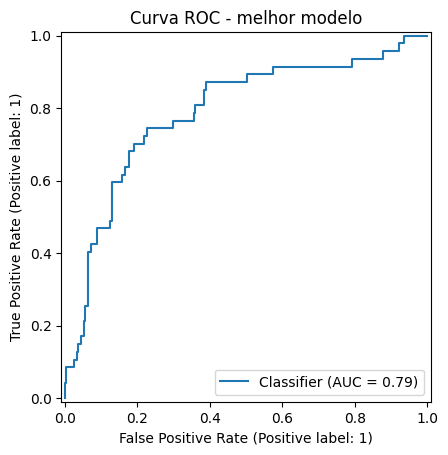

In [418]:
#Avaliando a capacidade do melhor modelo de diferenciar as classes por meio da curva ROC

if melhor_proba is not None:
    RocCurveDisplay.from_predictions(y_test, melhor_proba)
    plt.title("Curva ROC - melhor modelo")
    plt.show()

## 11.1 Comparação entre desempenho no treino e no teste

O F1-score do modelo final foi 0,728 no treino, aproximadamente 0,497 na validação cruzada e 0,444 no teste. A queda entre treino e validação indica overfitting moderado, embora menor do que o observado no Random Forest inicial.

A diferença entre validação e teste foi relativamente pequena, o que sugere que a estimativa de validação representou razoavelmente o desempenho em dados não vistos. Ainda assim, o conjunto é pequeno e contém poucos casos positivos, então pequenas variações na divisão podem alterar as métricas.

Não foram identificados sinais de underfitting no modelo final. O F1-score de treino (0,728) é substancialmente superior aos resultados de validação cruzada (0,497) e teste (0,444), demonstrando que o modelo possui capacidade suficiente para ajustar os dados de treinamento. O problema que pode ser observado é de generalização, caracterizado por overfitting moderado, porém não interpretado como incapacidade de aprendizagem.

In [419]:
# Comparação do modelo final
pred_treino_final = modelo_final.predict(X_train)
f1_treino_final = f1_score(y_train, pred_treino_final, zero_division=0)
f1_validacao_selecao = comparacao_validacao.iloc[0]["f1_cv"]
f1_teste_final = resultados_final_teste.loc[0, "f1_teste"]

comparacao_treino_validacao_teste = pd.DataFrame({
    "conjunto": ["Treino", "Validação cruzada", "Teste final"],
    "f1": [f1_treino_final, f1_validacao_selecao, f1_teste_final]
})

comparacao_treino_validacao_teste.round(3)

,conjunto,f1
0,Treino,0.728
1,Validação cruzada,0.497
2,Teste final,0.444


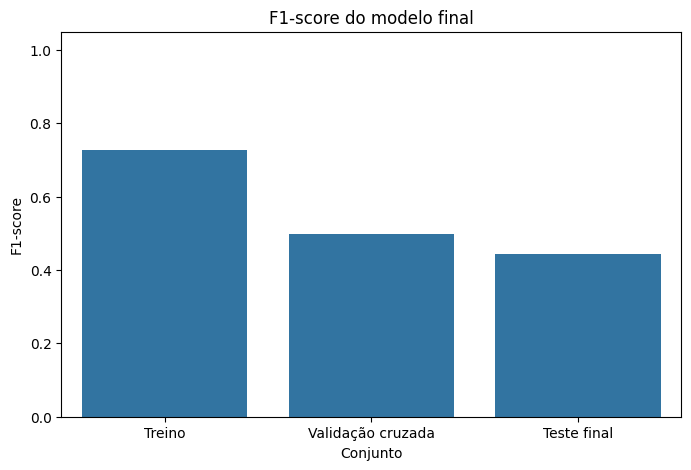

In [420]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparacao_treino_validacao_teste, x="conjunto", y="f1")
plt.title("F1-score do modelo final")
plt.xlabel("Conjunto")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.show()

## 11.2 Análise de erros

No conjunto de teste, o modelo realizou 239 classificações corretas e 55 incorretas. Os erros foram divididos em:

- 25 falsos negativos: funcionários que saíram, mas foram classificados como se fossem permanecer;
- 30 falsos positivos: funcionários que permaneceram, mas foram classificados como se fossem sair.

Os falsos negativos são especialmente relevantes: o modelo deixou de identificar 25 dos 47 desligamentos reais. Em uma aplicação prática, isso significaria que mais da metade dos casos de saída não receberia um alerta.

Os falsos positivos poderiam direcionar ações de retenção a funcionários que não deixariam a empresa. Como os custos dos dois erros são diferentes, um próximo passo importante seria ajustar o limiar de classificação de acordo com a prioridade da organização, em vez de usar automaticamente o corte de 0,5.


In [421]:
analise_erros = X_test.copy()
analise_erros["Attrition_real"] = y_test.values
analise_erros["Attrition_previsto"] = melhor_pred

if melhor_proba is not None:
    analise_erros["probabilidade_saida"] = melhor_proba

analise_erros["tipo_erro"] = np.where(
    analise_erros["Attrition_real"] == analise_erros["Attrition_previsto"],
    "acerto",
    np.where(
        (analise_erros["Attrition_real"] == 1) & (analise_erros["Attrition_previsto"] == 0),
        "falso_negativo",
        "falso_positivo"
    )
)

analise_erros["tipo_erro"].value_counts()

,count
tipo_erro,
acerto,239
falso_positivo,30
falso_negativo,25


In [422]:
analise_erros[analise_erros["tipo_erro"] != "acerto"].head(10)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_real,Attrition_previsto,probabilidade_saida,tipo_erro
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,...,2,3,1,0,0,0,0,1,0.698751,falso_positivo
1311,18,Non-Travel,1431,Research & Development,14,3,Medical,2,Female,33,...,4,1,0,0,0,0,0,1,0.622781,falso_positivo
318,27,Travel_Rarely,1220,Research & Development,5,3,Life Sciences,3,Female,85,...,2,2,4,3,1,2,0,1,0.672938,falso_positivo
602,30,Travel_Rarely,946,Research & Development,2,3,Medical,3,Female,52,...,4,2,0,0,0,0,0,1,0.503959,falso_positivo
985,31,Travel_Rarely,330,Research & Development,22,4,Medical,4,Male,98,...,3,2,10,2,6,7,1,0,0.364790,falso_negativo
136,51,Travel_Frequently,1150,Research & Development,8,4,Life Sciences,1,Male,53,...,2,3,4,2,0,3,1,0,0.298290,falso_negativo
45,41,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,49,...,0,3,22,15,15,8,1,0,0.204668,falso_negativo
603,45,Travel_Rarely,252,Research & Development,2,3,Life Sciences,2,Female,95,...,3,3,1,0,0,0,0,1,0.555644,falso_positivo
671,34,Travel_Rarely,546,Research & Development,10,3,Life Sciences,2,Male,83,...,3,3,1,0,1,0,0,1,0.586325,falso_positivo
1215,35,Travel_Frequently,146,Research & Development,2,4,Medical,1,Male,79,...,2,4,5,4,1,4,0,1,0.509888,falso_positivo


## 11.3 Importância das variáveis

A importância abaixo se refere especificamente ao Random Forest otimizado. Ela indica contribuição para as divisões das árvores, mas não demonstra causalidade. Variáveis correlacionadas também podem dividir importância entre si.

In [423]:
modelo_rf_treinado = melhor_rf.named_steps["modelo"]
preprocessador_treinado = melhor_rf.named_steps["preprocessador"]

nomes_features = preprocessador_treinado.get_feature_names_out()
importancias = modelo_rf_treinado.feature_importances_

importancia_df = pd.DataFrame({
    "variavel": nomes_features,
    "importancia": importancias
}).sort_values("importancia", ascending=False).head(15)

importancia_df

,variavel,importancia
9,num__MonthlyIncome,0.086077
16,num__TotalWorkingYears,0.084867
50,cat__OverTime_Yes,0.068171
19,num__YearsAtCompany,0.061763
0,num__Age,0.059403
15,num__StockOptionLevel,0.049350
22,num__YearsWithCurrManager,0.047139
49,cat__OverTime_No,0.046220
1,num__DailyRate,0.035975
7,num__JobLevel,0.034052


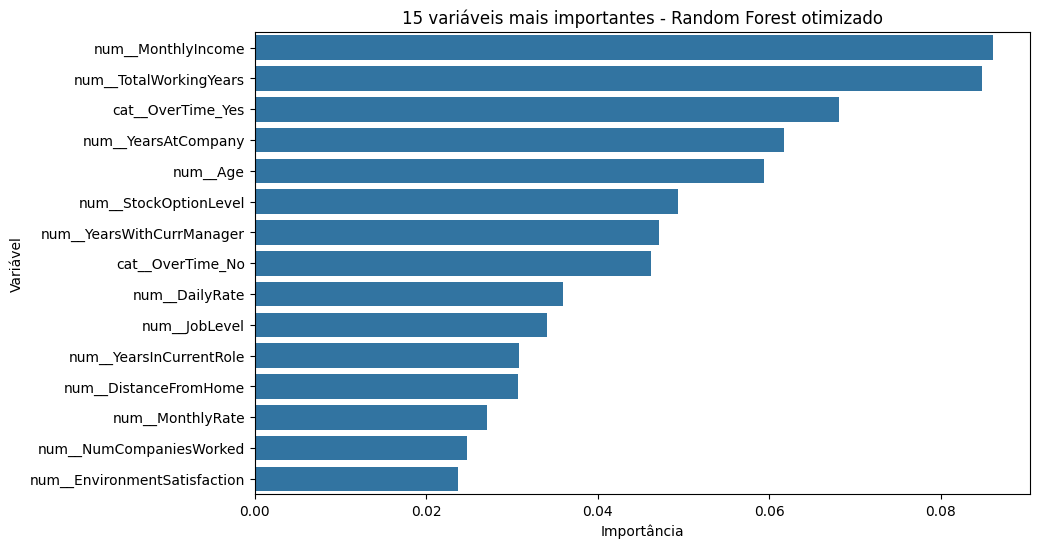

In [424]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_df, x="importancia", y="variavel")
plt.title("15 variáveis mais importantes - Random Forest otimizado")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## 12. Discussão crítica

O MVP atingiu o critério mínimo definido: os modelos supervisionados superaram o baseline em F1-score e demonstraram capacidade real, ainda que limitada, de identificar desligamentos.

A validação cruzada mostrou comportamentos distintos. A Regressão Logística foi estável e alcançou recall elevado, enquanto os modelos de árvores iniciais apresentaram overfitting. A otimização tornou o Random Forest mais equilibrado, elevando seu F1 médio de 0,284 para aproximadamente 0,497.

A vantagem do Random Forest otimizado sobre a Regressão Logística na validação foi pequena, cerca de 0,005 em F1. Portanto, não há evidência de superioridade ampla. Em um cenário que priorize encontrar o maior número possível de desligamentos, a Regressão Logística pode ser preferível por seu recall médio de 0,737 e maior simplicidade.

O resultado final também expõe uma limitação importante: o modelo selecionado deixou de identificar 25 dos 47 desligamentos no teste. Assim, ele não deveria ser usado isoladamente para decidir promoções, desligamentos, benefícios ou intervenções individuais.

A base é pequena, pública e representa um contexto organizacional específico. O modelo identifica associações, não causas. Antes de qualquer uso real, seriam necessárias validação externa, análise de equidade entre grupos, monitoramento temporal e revisão humana das decisões.

# 13. Comparação final dos modelos

Na validação cruzada, a Regressão Logística apresentou F1 médio de 0,492, recall de 0,737 e ROC-AUC de 0,827. O Gradient Boosting alcançou F1 de 0,456, com precisão alta e recall baixo. O Random Forest inicial teve F1 de 0,284 e forte overfitting.

Após a otimização, o Random Forest chegou a F1 médio próximo de 0,497 e foi selecionado pelo critério definido previamente. A diferença de aproximadamente 0,005 para a Regressão Logística é pequena e deve ser interpretada com cautela.

No teste reservado, o Random Forest otimizado obteve F1 de 0,444, recall de 0,468, precisão de 0,423 e ROC-AUC de 0,789. O resultado confirma que o modelo aprende padrões além do baseline, mas ainda com capacidade moderada para reconhecer a classe positiva.

A escolha final segue o F1-score, porém a Regressão Logística continua sendo uma alternativa relevante por ser mais simples, mais estável e ter apresentado recall superior na validação.

In [425]:
print("Comparação usada na seleção (somente treino/validação):")
display(comparacao_validacao.round(3))

print("Avaliação final no teste reservado:")
display(resultados_final_teste.round(3))

Comparação usada na seleção (somente treino/validação):


,modelo,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_cv_desvio,roc_auc_cv,f1_treino,gap_treino_cv,tempo_cv_seg
0,Random Forest otimizado,0.845,0.531,0.479,0.497,0.068,0.791,0.744,0.247,1.905
1,Regressão Logística,0.753,0.372,0.737,0.492,0.034,0.827,0.550,0.058,0.423
2,Gradient Boosting,0.872,0.734,0.337,0.456,0.077,0.813,0.897,0.440,2.526
3,Random Forest,0.861,0.876,0.174,0.284,0.078,0.805,1.000,0.716,4.048
4,Baseline - classe majoritária,0.838,0.000,0.000,0.000,0.000,0.500,0.000,0.000,4.314


Avaliação final no teste reservado:


,modelo,accuracy_teste,precision_teste,recall_teste,f1_teste,roc_auc_teste,tempo_treino_final_seg
0,Random Forest otimizado,0.813,0.423,0.468,0.444,0.789,0.314


# 14. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar `RANDOM_STATE = 42` | Garantir reprodutibilidade | Manter divisões e modelos aleatórios estáveis |
| Carregar dados por URL raw do GitHub | Evitar login e upload manual | Permitir execução integral no Colab |
| Usar `stratify=y` | Classe positiva corresponde a 16,12% da base | Preservar a proporção das classes |
| Reservar o teste até o final | Evitar seleção baseada no teste | Produzir avaliação final mais honesta |
| Usar pipelines | Ajustar transformações somente no treino | Reduzir risco de vazamento de dados |
| Remover identificador e colunas constantes | Não agregam informação generalizável | Reduzir ruído e memorização |
| Usar F1-score como métrica principal | Há desbalanceamento e custos nos dois tipos de erro | Equilibrar precision e recall |
| Aplicar `GridSearchCV` no Random Forest | Reduzir overfitting da configuração inicial | Melhorar generalização |

# 15. Conclusão do MVP

Este MVP teve como objetivo desenvolver e avaliar modelos de Machine Learning capazes de prever a saída de funcionários(as) a partir da base IBM HR Analytics Employee Attrition & Performance. O problema foi tratado como uma classificação binária, tendo Attrition como variável-alvo.

A preparação dos dados incluiu a remoção de colunas constantes e identificadoras, a transformação da variável-alvo, o tratamento das variáveis numéricas e categóricas e a divisão estratificada entre treino e teste. O pré-processamento foi realizado por meio de pipelines para evitar vazamento de dados. Como apenas 16,12% dos registros pertenciam à classe positiva, o F1-score foi adotado como principal métrica para comparação dos modelos.

Foram avaliados um baseline, Regressão Logística, Random Forest e Gradient Boosting. Entre os modelos iniciais, a Regressão Logística apresentou o melhor resultado na validação cruzada, com F1 médio de 0,492 e recall de 0,737. O Random Forest inicial apresentou forte overfitting, com F1 de 1,000 no treino e apenas 0,284 na validação.

Diante desse resultado, foi realizada a otimização dos hiperparâmetros do Random Forest. A melhor configuração reduziu a complexidade das árvores, elevou o F1 médio de validação para aproximadamente 0,497 e reduziu a diferença entre treino e validação de 0,716 para 0,231. Dessa forma o processo de otimização reduziu de forma significativa o overfitting observado inicialmente.

O Random Forest otimizado foi selecionado como modelo final por apresentar o maior F1 médio na validação cruzada. Entretanto, sua vantagem sobre a Regressão Logística foi consideravelmente pequena, o que indica que não houve superioridade ampla entre os modelos. No conjunto de teste, o modelo final obteve F1-score de 0,444, recall de 0,468 e ROC-AUC de 0,789. Além disso, deixou de identificar 25 dos 47 desligamentos reais, demonstrando uma limitação importante para sua aplicação prática.

A comparação entre treino, validação e teste mostrou que o modelo final ainda apresenta overfitting moderado, embora menor que o observado inicialmente. Não foram identificados sinais de underfitting, pois o modelo demonstrou capacidade de aprender os padrões dos dados de treinamento. O principal problema está relacionado à perda de desempenho em dados não vistos.

De forma geral, o objetivo do MVP foi alcançado. Foi desenvolvido um fluxo completo e reproduzível de Machine Learning, com preparação dos dados, comparação de modelos, otimização de hiperparâmetros, avaliação em dados não vistos e análise crítica dos resultados. Entretanto, devido ao tamanho e ao desbalanceamento da base, à ausência de validação externa e ao overfitting ainda presente, o modelo não deve ser utilizado isoladamente para orientar decisões reais de gestão de pessoas.

Como próximos passos, recomenda-se testar novas estratégias de regularização e tratamento do desbalanceamento, ajustar o limiar de classificação, avaliar outros modelos e validar a solução em uma base maior e com dados reais.

